In [ ]:
!pip install transformers accelerate segmentation-models-pytorch albumentations \
             opencv-python matplotlib scikit-learn pycocotools roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 62.9 MB/s eta 0:00:00


In [ ]:
import os, cv2, json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import SegformerForSemanticSegmentation, SegformerConfig
import segmentation_models_pytorch as smp

from pycocotools.coco import COCO

print("All imports OK")

All imports OK


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="rZo2uFSwFj9aHJPSaF2u")
project = rf.workspace("capstone-project-qiyij").project("combined-dataset-seg-full-vkwbr")
version = project.version(1)
dataset = version.download("coco-segmentation")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Combined-Dataset-Seg-Full-1 in coco-segmentation:: 100%|██████████| 9640/9640 [00:05<00:00, 1761.75it/s]


In [ ]:
TRAIN_DIR  = "/content/Combined-Dataset-Seg-Full-1/train"
VALID_DIR  = "/content/Combined-Dataset-Seg-Full-1/valid"
TEST_DIR   = "/content/Combined-Dataset-Seg-Full-1/test"
TRAIN_COCO = f"{TRAIN_DIR}/_annotations.coco.json"
VALID_COCO = f"{VALID_DIR}/_annotations.coco.json"
TEST_COCO  = f"{TEST_DIR}/_annotations.coco.json"

IMG_SIZE   = 512
BATCH_SIZE = 4
EPOCHS   = 80
LR       = 1e-4
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

SEG_OUT_SIZE = IMG_SIZE // 4
print(f"Device: {DEVICE}  |  IMG_SIZE: {IMG_SIZE}")

Device: cuda  |  IMG_SIZE: 512


In [ ]:
def apply_clahe(image_rgb: np.ndarray) -> np.ndarray:
    lab   = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

In [ ]:
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=0, border_mode=cv2.BORDER_CONSTANT, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(var_limit=(5.0, 15.0), p=0.2),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])


val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
Argument(s) 'var_limit' are not valid for transform GaussNoise


In [ ]:
class CocoFractureDataset(Dataset):
    def __init__(self, image_dir, annotation_path, transform=None, use_clahe=True):
        self.image_dir = image_dir
        self.coco      = COCO(annotation_path)
        self.image_ids = list(self.coco.imgs.keys())
        self.transform = transform
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id   = self.image_ids[idx]
        image_info = self.coco.loadImgs(image_id)[0]

        image = cv2.imread(os.path.join(self.image_dir, image_info["file_name"]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.use_clahe:
            image = apply_clahe(image)

        h, w = image_info["height"], image_info["width"]
        mask = np.zeros((h, w), dtype=np.uint8)
        for ann in self.coco.loadAnns(self.coco.getAnnIds(imgIds=image_id)):
            mask = np.maximum(mask, self.coco.annToMask(ann))

        if self.transform:
            aug   = self.transform(image=image, mask=mask.astype("float32"))
            image = aug["image"]
            mask  = aug["mask"].unsqueeze(0).float()

        return image, mask


train_dataset = CocoFractureDataset(TRAIN_DIR, TRAIN_COCO, train_transform)
val_dataset   = CocoFractureDataset(VALID_DIR, VALID_COCO, val_transform)
test_dataset  = CocoFractureDataset(TEST_DIR,  TEST_COCO,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

loading annotations into memory...
Done (t=0.23s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Train: 6744 | Val: 1448 | Test: 1440


In [ ]:

class SegFormerBinaryWrapper(nn.Module):
    """
    Wraps HuggingFace SegformerForSemanticSegmentation for binary segmentation.
    Output: (B, 1, H, W) logits at full input resolution.
    """
    def __init__(self, pretrained_name="nvidia/mit-b2", img_size=512):
        super().__init__()
        self.img_size = img_size

        config = SegformerConfig.from_pretrained(
            pretrained_name,
            num_labels=2,
            ignore_mismatched_sizes=True
        )
        self.segformer = SegformerForSemanticSegmentation.from_pretrained(
            pretrained_name,
            config=config,
            ignore_mismatched_sizes=True
        )

        in_ch = self.segformer.decode_head.classifier.in_channels
        self.segformer.decode_head.classifier = nn.Conv2d(in_ch, 1, kernel_size=1)

    def forward(self, pixel_values):
        outputs = self.segformer(pixel_values=pixel_values)
        logits = F.interpolate(
            outputs.logits,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False
        )
        return logits   # (B, 1, H, W)


model = SegFormerBinaryWrapper(pretrained_name="nvidia/mit-b2", img_size=IMG_SIZE)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params / 1e6:.2f}M")


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Trainable parameters: 27.35M


In [ ]:
tversky_loss = smp.losses.TverskyLoss(mode="binary", alpha=0.4, beta=0.6)
focal_loss   = smp.losses.FocalLoss(mode="binary")
def combined_loss(preds, masks):
    return 0.6 * tversky_loss(preds, masks) + 0.4 * focal_loss(preds, masks)

optimizer = torch.optim.AdamW([
    {"params": model.segformer.segformer.parameters(), "lr": LR * 0.1},
    {"params": model.segformer.decode_head.parameters(), "lr": LR},
], weight_decay=0.01)

from transformers import get_cosine_schedule_with_warmup
total_steps  = EPOCHS * len(train_loader)
warmup_steps = int(0.05 * total_steps)   # 5% warmup
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

In [ ]:
def calculate_metrics(preds, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(preds) > threshold).float()
    tp = (preds * masks).sum()
    fp = (preds * (1 - masks)).sum()
    fn = ((1 - preds) * masks).sum()

    dice      = (2 * tp) / (2 * tp + fp + fn + eps)
    iou       = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    return dice.item(), iou.item(), precision.item(), recall.item()

In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    totals = {"loss": 0, "dice": 0, "iou": 0}
    for images, masks in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        dice, iou, *_ = calculate_metrics(outputs.detach(), masks)
        totals["loss"] += loss.item()
        totals["dice"] += dice
        totals["iou"]  += iou
    n = len(loader)
    return totals["loss"]/n, totals["dice"]/n, totals["iou"]/n


def validate_one_epoch(model, loader):
    model.eval()
    totals = {"loss": 0, "dice": 0, "iou": 0, "prec": 0, "rec": 0}
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            loss    = combined_loss(outputs, masks)
            dice, iou, prec, rec = calculate_metrics(outputs, masks)
            totals["loss"] += loss.item()
            totals["dice"] += dice
            totals["iou"]  += iou
            totals["prec"] += prec
            totals["rec"]  += rec
    n = len(loader)
    return totals["loss"]/n, totals["dice"]/n, totals["iou"]/n, totals["prec"]/n, totals["rec"]/n

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

CKPT_DIR  = "/content/drive/MyDrive/fracture_segformer_checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
BEST_CKPT = f"{CKPT_DIR}/best_segformer_b2.pth"

try:
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch   = ckpt["epoch"]
    history       = ckpt["history"]
    best_val_dice = ckpt["best_val_dice"]

    for _ in range(start_epoch):
        scheduler.step()

    print(f"Resumed from epoch {start_epoch}, best Dice: {best_val_dice:.4f}")
except FileNotFoundError:
    start_epoch   = 0
    best_val_dice = 0.0
    history = {k: [] for k in ["train_loss", "val_loss", "train_dice", "val_dice",
                                "train_iou",  "val_iou",  "val_precision", "val_recall"]}
    print("No checkpoint found — starting fresh.")

Mounted at /content/drive
Resumed from epoch 68, best Dice: 0.5778


Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate


In [ ]:
patience          = 20
epochs_no_improve = 0

for epoch in range(start_epoch, EPOCHS):
    tr_loss, tr_dice, tr_iou             = train_one_epoch(model, train_loader, optimizer)
    va_loss, va_dice, va_iou, va_p, va_r = validate_one_epoch(model, val_loader)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_dice"].append(tr_dice)
    history["val_dice"].append(va_dice)
    history["train_iou"].append(tr_iou)
    history["val_iou"].append(va_iou)
    history["val_precision"].append(va_p)
    history["val_recall"].append(va_r)

    print(f"Epoch [{epoch+1:>2}/{EPOCHS}]  "
          f"Train Loss: {tr_loss:.4f}  Dice: {tr_dice:.4f}  |  "
          f"Val Loss: {va_loss:.4f}  Dice: {va_dice:.4f}  IoU: {va_iou:.4f}  "
          f"P: {va_p:.4f}  R: {va_r:.4f}")

    if va_dice > best_val_dice:
        best_val_dice     = va_dice
        epochs_no_improve = 0
        torch.save({
            "epoch":                epoch + 1,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history":              history,
            "best_val_dice":        best_val_dice,
        }, BEST_CKPT)
        print(f"  ✓ Best model saved (Dice: {best_val_dice:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nTraining complete. Best Val Dice: {best_val_dice:.4f}")

Epoch [69/80]  Train Loss: 0.2545  Dice: 0.5754  |  Val Loss: 0.2520  Dice: 0.5772  IoU: 0.4231  P: 0.5386  R: 0.6606
Epoch [70/80]  Train Loss: 0.2519  Dice: 0.5793  |  Val Loss: 0.2516  Dice: 0.5773  IoU: 0.4230  P: 0.5357  R: 0.6649
Epoch [71/80]  Train Loss: 0.2516  Dice: 0.5802  |  Val Loss: 0.2526  Dice: 0.5776  IoU: 0.4239  P: 0.5463  R: 0.6510
Epoch [72/80]  Train Loss: 0.2549  Dice: 0.5746  |  Val Loss: 0.2520  Dice: 0.5775  IoU: 0.4234  P: 0.5397  R: 0.6596
Epoch [73/80]  Train Loss: 0.2527  Dice: 0.5787  |  Val Loss: 0.2527  Dice: 0.5779  IoU: 0.4240  P: 0.5474  R: 0.6498
  ✓ Best model saved (Dice: 0.5779)
Epoch [74/80]  Train Loss: 0.2535  Dice: 0.5773  |  Val Loss: 0.2521  Dice: 0.5775  IoU: 0.4234  P: 0.5413  R: 0.6575
Epoch [75/80]  Train Loss: 0.2502  Dice: 0.5824  |  Val Loss: 0.2519  Dice: 0.5769  IoU: 0.4226  P: 0.5355  R: 0.6643
Epoch [76/80]  Train Loss: 0.2505  Dice: 0.5817  |  Val Loss: 0.2521  Dice: 0.5777  IoU: 0.4236  P: 0.5410  R: 0.6582
Epoch [77/80]  Train

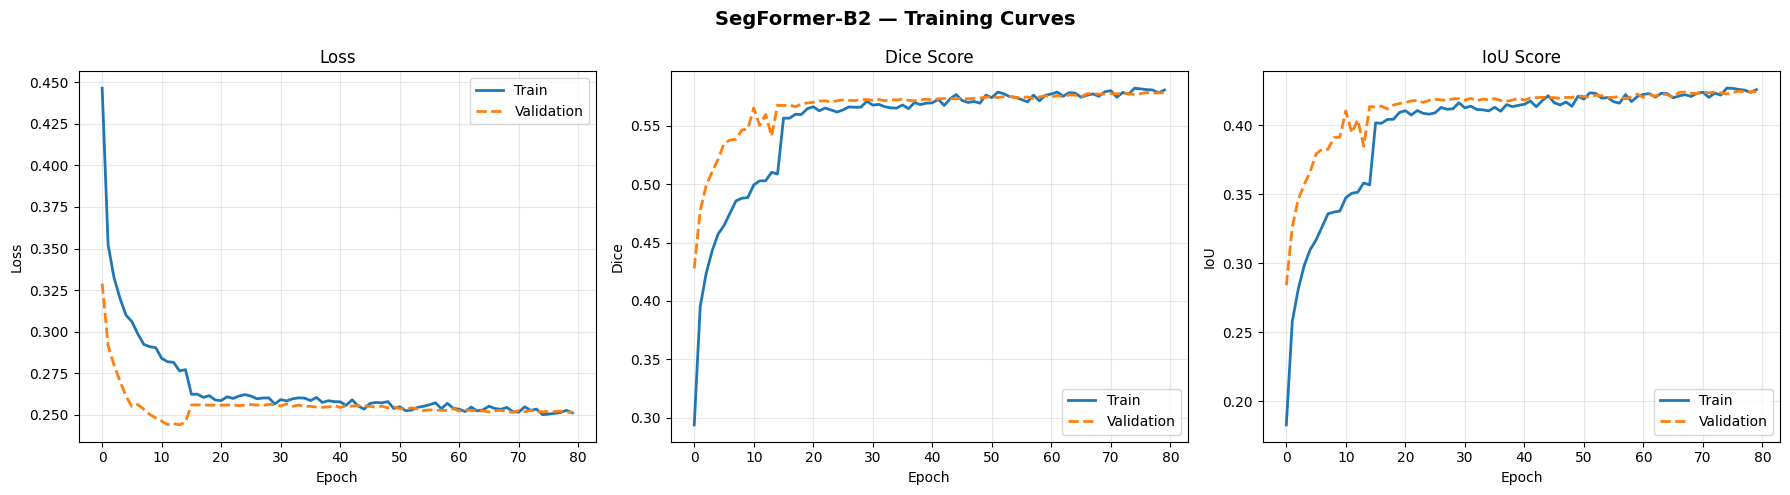

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SegFormer-B2 — Training Curves", fontsize=14, fontweight="bold")

for ax, (tr_key, va_key, title, ylabel) in zip(axes, [
    ("train_loss", "val_loss", "Loss",       "Loss"),
    ("train_dice", "val_dice", "Dice Score", "Dice"),
    ("train_iou",  "val_iou",  "IoU Score",  "IoU"),
]):
    ax.plot(history[tr_key], label="Train", linewidth=2)
    ax.plot(history[va_key], label="Validation", linewidth=2, linestyle="--")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/segformer_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
best_thresh, best_dice = 0.5, 0.0
for thresh in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]:
    total_dice = 0
    model.eval()
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            preds = model(images)
            d, *_ = calculate_metrics(preds, masks, threshold=thresh)
            total_dice += d
    avg = total_dice / len(val_loader)
    print(f"Threshold {thresh:.2f} → Dice {avg:.4f}")
    if avg > best_dice:
        best_dice, best_thresh = avg, thresh

print(f"\nBest threshold: {best_thresh} → Dice {best_dice:.4f}")

Threshold 0.30 → Dice 0.5765
Threshold 0.35 → Dice 0.5773
Threshold 0.40 → Dice 0.5778
Threshold 0.45 → Dice 0.5780
Threshold 0.50 → Dice 0.5783
Threshold 0.55 → Dice 0.5784

Best threshold: 0.55 → Dice 0.5784


In [ ]:
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

te_loss, te_dice, te_iou, te_prec, te_rec = validate_one_epoch(model, test_loader)

print("=" * 50)
print("SegFormer-B2 — TEST SET RESULTS")
print("=" * 50)
print(f"Loss:      {te_loss:.4f}")
print(f"Dice:      {te_dice:.4f}")
print(f"IoU:       {te_iou:.4f}")
print(f"Precision: {te_prec:.4f}")
print(f"Recall:    {te_rec:.4f}")
print("=" * 50)

SegFormer-B2 — TEST SET RESULTS
Loss:      0.2493
Dice:      0.5870
IoU:       0.4323
Precision: 0.5703
Recall:    0.6416


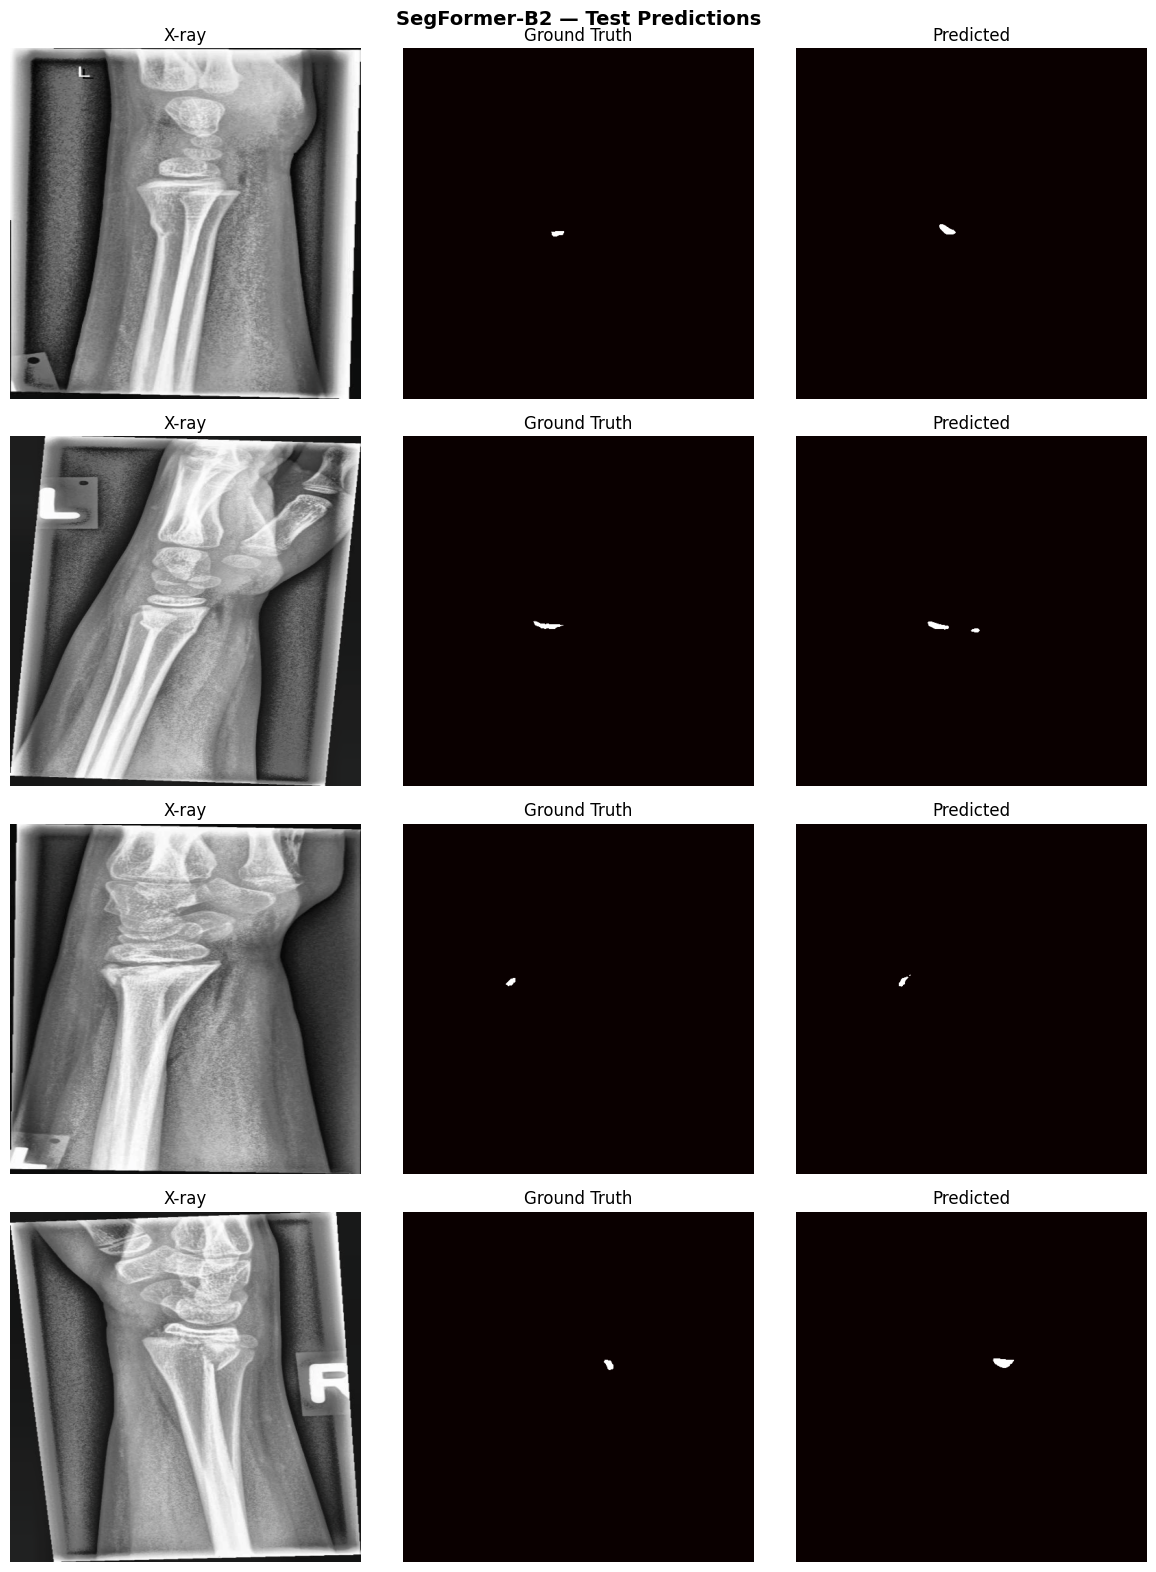

In [ ]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

images_b, masks_b = next(iter(test_loader))
with torch.no_grad():
    preds_b = (torch.sigmoid(model(images_b.to(DEVICE))) > 0.5).float().cpu()

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle("SegFormer-B2 — Test Predictions", fontsize=14, fontweight="bold")

for i in range(min(4, images_b.shape[0])):
    img = np.clip(std * images_b[i].permute(1,2,0).numpy() + mean, 0, 1)
    axes[i][0].imshow(img);              axes[i][0].set_title("X-ray");         axes[i][0].axis("off")
    axes[i][1].imshow(masks_b[i][0], cmap="hot"); axes[i][1].set_title("Ground Truth"); axes[i][1].axis("off")
    axes[i][2].imshow(preds_b[i][0], cmap="hot"); axes[i][2].set_title("Predicted");    axes[i][2].axis("off")

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/segformer_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Combined comparison table (load U-Net++ results if available) ──────────
segformer_results = {
    "model":     "SegFormer-B2",
    "dice":      round(te_dice, 4),
    "iou":       round(te_iou, 4),
    "precision": round(te_prec, 4),
    "recall":    round(te_rec, 4),
    "loss":      round(te_loss, 4),
    "img_size":  IMG_SIZE,
    "epochs":    len(history["val_dice"]),
}

with open(f"{CKPT_DIR}/segformer_results.json", "w") as f:
    json.dump(segformer_results, f, indent=2)

# ── Try to build full 3-model comparison table ─────────────────────────────
baseline = {
    "model":     "U-Net ResNet34 (Baseline)",
    "dice":      0.3473,
    "iou":       0.2163,
    "precision": 0.2403,
    "recall":    0.7006,
}

unetpp_path = "/content/drive/MyDrive/fracture_unetpp_checkpoints/unetpp_results.json"
try:
    with open(unetpp_path) as f:
        unetpp_results = json.load(f)
except FileNotFoundError:
    unetpp_results = {"model": "U-Net++ EfficientNet-B4", "dice": "?", "iou": "?", "precision": "?", "recall": "?"}

print("\n" + "=" * 70)
print(f"{'Model':<30} {'Dice':>8} {'IoU':>8} {'Precision':>10} {'Recall':>8}")
print("=" * 70)
for r in [baseline, unetpp_results, segformer_results]:
    print(f"{r['model']:<30} {str(r['dice']):>8} {str(r['iou']):>8} {str(r['precision']):>10} {str(r['recall']):>8}")
print("=" * 70)


Model                              Dice      IoU  Precision   Recall
U-Net ResNet34 (Baseline)        0.3473   0.2163     0.2403   0.7006
U-Net++ EfficientNet-B4            0.59   0.4369     0.5718   0.6464
SegFormer-B2                      0.587   0.4323     0.5703   0.6416
